In [3]:
## 1. Data Loading & Cleaning

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import chi2_contingency
data=pd.read_excel(r"C:\Healthcare data analysis\Data\cleaned healthcare_dataset.xlsx")
data.info()
data['Gender'].value_counts()
data['Medical Condition'].value_counts()
data.groupby('Medical Condition')['Billing Amount'].mean()
data.corr(numeric_only=True)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54966 entries, 0 to 54965
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Name                54966 non-null  object        
 1   Age                 54966 non-null  int64         
 2   Gender              54966 non-null  object        
 3   Blood Type          54966 non-null  object        
 4   Medical Condition   54966 non-null  object        
 5   Date of Admission   54966 non-null  datetime64[ns]
 6   Doctor              54966 non-null  object        
 7   Hospital            54966 non-null  object        
 8   Insurance Provider  54966 non-null  object        
 9   Billing Amount      54966 non-null  float64       
 10  Room Number         54966 non-null  int64         
 11  Admission Type      54966 non-null  object        
 12  Discharge Date      54966 non-null  datetime64[ns]
 13  Medication          54966 non-null  object    

,Age,Billing Amount,Room Number
Age,1.000000,-0.003427,-0.000352
Billing Amount,-0.003427,1.000000,-0.003930
Room Number,-0.000352,-0.003930,1.000000


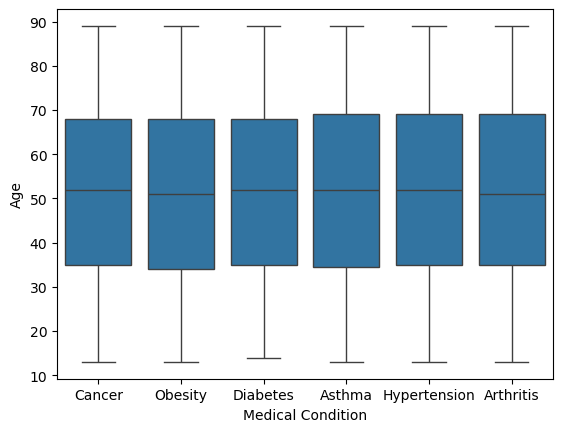

In [4]:
## 2. Exploratory Data Analysis

# medical condition patterns
data['Medical Condition'].value_counts()
data.groupby('Medical Condition')['Age'].mean()
pd.crosstab(data['Medical Condition'],data['Gender'])

#billing financial analysis
data.groupby('Medical Condition')['Billing Amount'].mean().sort_values(ascending=False)
data.groupby('Insurance Provider')['Billing Amount'].mean()
data['Admission Type'].value_counts()

#Medication & test result patterns
data['Medication'].value_counts()
data['Test Results'].value_counts()
pd.crosstab(data['Medication'], data['Test Results'])

#IS AGE RELATED to certain medical condition

sns.boxplot(x='Medical Condition', y='Age', data=data)
plt.show()


  Date of Admission Discharge Date  length stay DAYS
0        2024-01-31     2024-02-02                 2
1        2019-08-20     2019-08-26                 6
2        2022-09-22     2022-10-07                15
3        2020-11-18     2020-12-18                30
4        2022-09-19     2022-10-09                20
Medical Condition
Arthritis       15.504231
Asthma          15.677295
Cancer          15.501204
Diabetes        15.430664
Hypertension    15.436236
Obesity         15.447627
Name: length stay DAYS, dtype: float64
Admission Type
Elective     15.511178
Emergency    15.584134
Urgent       15.403839
Name: length stay DAYS, dtype: float64


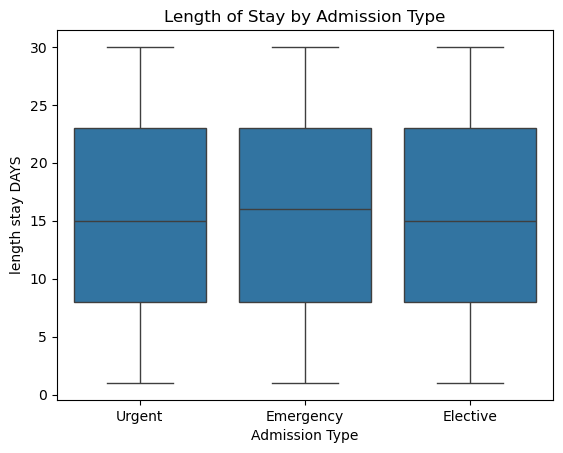

In [16]:
## 3. Length of Stay Analysis

data['Date of Admission'] = pd.to_datetime(data['Date of Admission'])
data['Discharge Date'] = pd.to_datetime(data['Discharge Date'])
data['length stay DAYS'] = (data['Discharge Date'] - data['Date of Admission']).dt.days
print(data[['Date of Admission', 'Discharge Date', 'length stay DAYS']].head())
# Average length of stay by condition
print(data.groupby('Medical Condition')['length stay DAYS'].mean())

# Average length of stay by admission type
print(data.groupby('Admission Type')['length stay DAYS'].mean())

# Distribution check
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(x='Admission Type', y='length stay DAYS', data=data)
plt.title('Length of Stay by Admission Type')
plt.show()

In [8]:
## 5. Predictive Modeling

df = data[['Age', 'Medical Condition', 'Admission Type', 'Insurance Provider', 'Billing Amount']]

df = pd.get_dummies(df, drop_first=True)

X = df.drop('Billing Amount', axis=1)
y = df['Billing Amount']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))

R2 Score: -0.0003404489400096189


In [17]:
## 4. Statistical Testing (Chi-Square)

# Test 1: Medication vs Test Results
table1 = pd.crosstab(data['Medication'], data['Test Results'])
chi2, p, dof, expected = chi2_contingency(table1)
print("Medication vs Test Results")
print(f"Chi2: {chi2:.4f}, p-value: {p:.4f}")
print()

# Test 2: Medical Condition vs Gender
table2 = pd.crosstab(data['Medical Condition'], data['Gender'])
chi2, p, dof, expected = chi2_contingency(table2)
print("Medical Condition vs Gender")
print(f"Chi2: {chi2:.4f}, p-value: {p:.4f}")

# Test 3: Medical Condition vs Admission Type
table3 = pd.crosstab(data['Medical Condition'], data['Admission Type'])
chi2, p, dof, expected = chi2_contingency(table3)
print("Medical Condition vs Admission Type")
print(f"Chi2: {chi2:.4f}, p-value: {p:.4f}")
print()

# Interpretation (add comments like this under every test)
# p > 0.05 for all three tests → no statistically significant relationship
# This confirms categorical variables are independent of each other in this dataset

Medication vs Test Results
Chi2: 3.8519, p-value: 0.8702

Medical Condition vs Gender
Chi2: 1.0721, p-value: 0.9565
Medical Condition vs Admission Type
Chi2: 17.8903, p-value: 0.0568



In [ ]:
## 6. Key Findings

## Key Findings
- Numeric features (Age, Billing Amount, Room Number) show near-zero correlation (all |r| < 0.01)
- Age, Gender, and Length of Stay distributions are nearly identical across all medical conditions
- Chi-square tests confirm no significant relationship between Medication & Test Results (p=0.87),
  Condition & Gender (p=0.96), or Condition & Admission Type (p=0.057)
- Linear Regression and Random Forest models both fail to predict Billing Amount (R² ≈ 0)
- Conclusion: dataset's categorical/numeric fields appear randomly/independently generated